In [95]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score, log_loss
from sklearn.compose import ColumnTransformer,make_column_transformer,make_column_selector
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder




In [96]:
df=pd.read_csv("../Datasets/HR_comma_sep.csv")

In [97]:
X=df.drop(columns=["left"])
Y=df["left"]

In [98]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [99]:
one_hot_encoder=OneHotEncoder(drop="first",handle_unknown="ignore",sparse_output=False).set_output(transform="pandas")
# X_train_encoder=one_hot_encoder.fit_transform(X_train)
# X_test_encoder=one_hot_encoder.transform(X_test)


In [100]:
prms = make_column_transformer(
    (one_hot_encoder,make_column_selector(dtype_include="object")),
    remainder="passthrough",
    verbose_feature_names_out=False
)

In [101]:
prms=prms.set_output(transform="pandas")
x_train_prms=prms.fit_transform(X_train)
x_test_prms=prms.transform(X_test)

In [102]:
ddc=DecisionTreeClassifier(max_depth=2,random_state=25,criterion="gini")
ddc.fit(x_train_prms, Y_train)
y_pred=ddc.predict(x_test_prms)
print(accuracy_score(y_pred,Y_test))
print(confusion_matrix(y_pred,Y_test))
print(classification_report(Y_test,y_pred))

0.8501889308735274
[[3366  611]
 [  63  459]]
              precision    recall  f1-score   support

           0       0.85      0.98      0.91      3429
           1       0.88      0.43      0.58      1070

    accuracy                           0.85      4499
   macro avg       0.86      0.71      0.74      4499
weighted avg       0.85      0.85      0.83      4499



In [103]:
import matplotlib.pyplot as plt

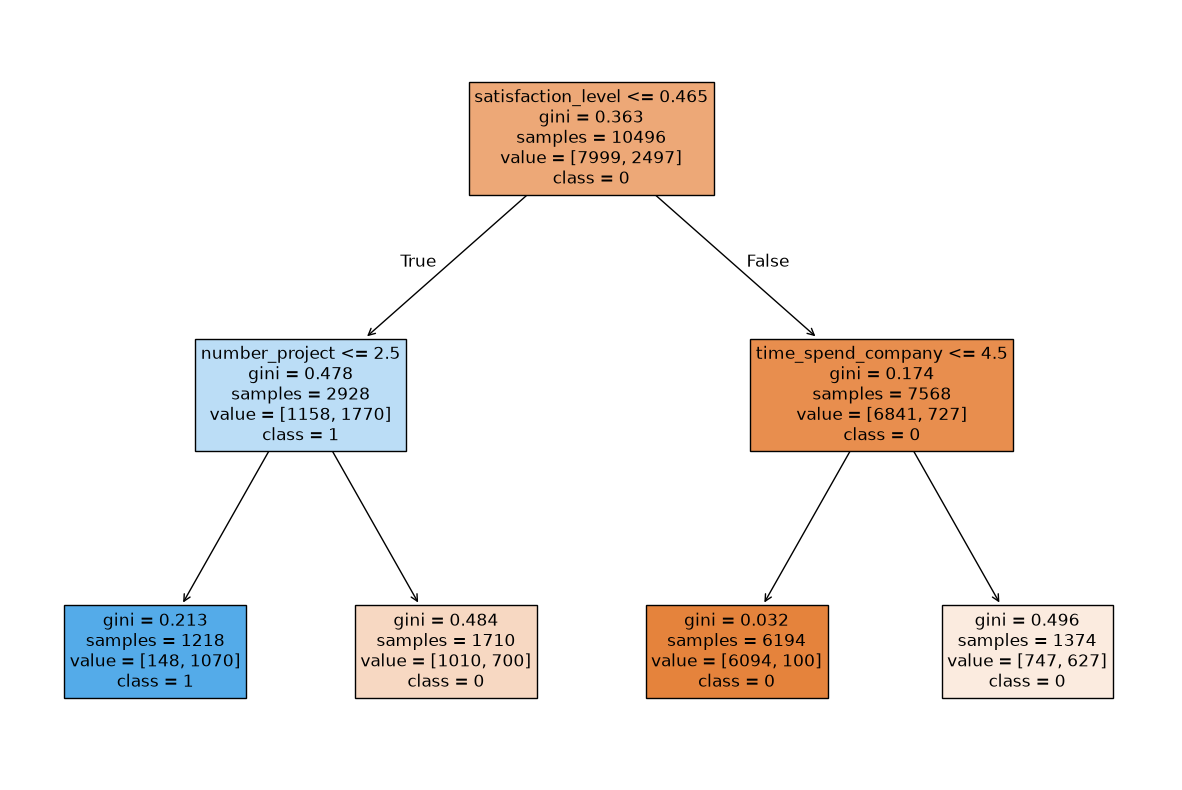

In [104]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(15, 10))

plot_tree(
    ddc,
    feature_names=list(x_train_prms.columns),
    class_names=['0', '1'],
    filled=True,
    fontsize=12
)

plt.show()

In [105]:
cs=[3,4,5,6,7,8,9]
score=list()
for c in cs:
    ddc=DecisionTreeClassifier(max_depth=c,random_state=25,criterion="gini")
    ddc.fit(x_train_prms, Y_train)
    y_pred=ddc.predict(x_test_prms)
    score.append([c, f1_score(Y_test,y_pred,pos_label=1)])
score_df=pd.DataFrame(score,columns=["depth","f1_score"]).sort_values(by="f1_score",ascending=False)
print(score_df)


   depth  f1_score
6      9  0.962751
4      7  0.959770
5      8  0.959311
3      6  0.955981
2      5  0.951382
1      4  0.934967
0      3  0.909672


In [106]:
depths=[3,4,5,6,7,8,9,10,11,None]
leaves=[1,50,75,100,150]
splits_lists=[2,50,75,100,150]
score=[]
for d in depths:
    for l in leaves:
        for s in splits_lists:
            ddc=DecisionTreeClassifier(max_depth=d,min_samples_leaf=l,min_samples_split=s,random_state=25,criterion="gini")
            ddc.fit(x_train_prms, Y_train)
            y_pred=ddc.predict(x_test_prms)
            score.append([d, l,s,f1_score(Y_test,y_pred,pos_label=1)])
score_df=pd.DataFrame(score,columns=["depth","min_samples_leaf","min_samples_split","f1_score"]).sort_values(by="f1_score",ascending=False)
print(score_df.head())


     depth  min_samples_leaf  min_samples_split  f1_score
150    9.0                 1                  2  0.962751
175   10.0                 1                  2  0.962013
225    NaN                 1                  2  0.961290
151    9.0                 1                 50  0.960539
177   10.0                 1                 75  0.960539


In [107]:
print(score_df.shape)

(250, 4)


In [108]:
# building best model
best_model=DecisionTreeClassifier(max_depth=9,random_state=25,criterion="gini",min_samples_split=2,min_samples_leaf=1)
x_trms=prms.fit_transform(X)
best_model.fit(x_trms, Y)
# what is importance
df_imp=pd.DataFrame({'feature':x_trms.columns,"importance":best_model.feature_importances_}).sort_values(by="importance",ascending=False)
print(df_imp)
# y_pred=dddc.predict(x_test_prms)
# print(accuracy_score(y_pred,Y_test))
# print(confusion_matrix(y_pred,Y_test))
# print(classification_report(Y_test,y_pred))


                   feature  importance
11      satisfaction_level    0.519846
15      time_spend_company    0.148528
12         last_evaluation    0.143526
13          number_project    0.108963
14    average_montly_hours    0.074325
9               salary_low    0.002113
10           salary_medium    0.000770
8     Department_technical    0.000612
7       Department_support    0.000431
0         Department_RandD    0.000373
2            Department_hr    0.000319
1    Department_accounting    0.000193
4     Department_marketing    0.000000
5   Department_product_mng    0.000000
6         Department_sales    0.000000
3    Department_management    0.000000
16           Work_accident    0.000000
17   promotion_last_5years    0.000000


Hello


In [109]:
df_glass=pd.read_csv("../Datasets/Glass.csv")
# depth 2,3,4,5,None
# leaves 1,5,10,20
# split 2,5,10,20
# best model
df_glass.columns

Index(['RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type'], dtype='str')

In [110]:
encoder=LabelEncoder()


In [111]:
X=df_glass.drop(columns=["Type"])
Y=encoder.fit_transform(df_glass["Type"])

In [112]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.3,random_state=25,stratify=Y)

In [130]:
depths=[2,3,4,5,None]
leaves=[1,5,10,20]
splits_lists=[2,5,10,20]

score=[]

for d in depths:
    for l in leaves:
        for s in splits_lists:

            ddc=DecisionTreeClassifier(
                max_depth=d,
                min_samples_leaf=l,
                min_samples_split=s,
                random_state=25,
                criterion="gini"
            )

            ddc.fit(X_train, Y_train)
            y_pred=ddc.predict(X_test)
            y_pred_proba = ddc.predict_proba(X_test)

            loss = log_loss(Y_test, y_pred_proba)

            score.append([d, l, s, loss,accuracy_score(Y_test,y_pred)])


score_df=pd.DataFrame(
    score,
    columns=[
        "depth",
        "min_samples_leaf",
        "min_samples_split",
        "log_loss",
        "accuracy_score"
    ]
).sort_values(
    by=["log_loss","accuracy_score"],
    ascending=[True,False]
)

print(score_df.head())

    depth  min_samples_leaf  min_samples_split  log_loss  accuracy_score
12    2.0                20                  2  1.627429        0.630769
13    2.0                20                  5  1.627429        0.630769
14    2.0                20                 10  1.627429        0.630769
15    2.0                20                 20  1.627429        0.630769
44    4.0                20                  2  1.932912        0.630769


In [131]:
score_df=pd.DataFrame(
    score,
    columns=[
        "depth",
        "min_samples_leaf",
        "min_samples_split",
        "log_loss",
        "accuracy_score"
    ]
).sort_values(
    by="accuracy_score",
    ascending=False
)

print(score_df.head())

    depth  min_samples_leaf  min_samples_split  log_loss  accuracy_score
66    NaN                 1                 10  5.315433        0.723077
70    NaN                 5                 10  5.919950        0.707692
69    NaN                 5                  5  5.919950        0.707692
68    NaN                 5                  2  5.919950        0.707692
24    3.0                10                  2  1.983123        0.676923


In [128]:
best_model=DecisionTreeClassifier(max_depth=2,random_state=25,criterion="gini",min_samples_split=2,min_samples_leaf=20)
# x_trms=prms.fit_transform(X)
best_model.fit(X_train, Y_train)
# what is importance
df_imp=pd.DataFrame({'feature':X.columns,"importance":best_model.feature_importances_}).sort_values(by="importance",ascending=False)
print(df_imp)

  feature  importance
7      Ba    0.642439
3      Al    0.357561
0      RI    0.000000
2      Mg    0.000000
1      Na    0.000000
4      Si    0.000000
5       K    0.000000
6      Ca    0.000000
8      Fe    0.000000


In [115]:
from sklearn.metrics import log_loss

In [129]:
best_model=DecisionTreeClassifier(max_depth=2,random_state=25,criterion="gini",min_samples_split=2,min_samples_leaf=20)
# x_trms=prms.fit_transform(X)
best_model.fit(X, Y)
# what is importance
df_imp=pd.DataFrame({'feature':X.columns,"importance":best_model.feature_importances_}).sort_values(by="importance",ascending=False)
print(df_imp)

  feature  importance
7      Ba    0.618193
3      Al    0.381807
0      RI    0.000000
2      Mg    0.000000
1      Na    0.000000
4      Si    0.000000
5       K    0.000000
6      Ca    0.000000
8      Fe    0.000000
